# Physics 5BL Lab 10 — RC and RLC Circuits
## Full Analysis Notebook

**Experiments:**
- **1A**: RC Discharge — time constant measurement (R = 10 kΩ, C = 47 μF)
- **1B**: Homemade Capacitor — charging curve, capacitance extraction
- **2A**: RLC Underdamped — damped oscillation, α and ω₀ extraction
- **2B**: RLC Overdamped — exponential decay, decay constant extraction

**Circuit component tolerances:**
- Resistors: ±1%
- Capacitors: ±5%
- Inductor: ±10%
- Function generator internal resistance: 50 Ω


## Imports and Plot Styling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit

# ── Plot aesthetics ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'lines.linewidth': 1.8,
})

# ── Agreement test helper ────────────────────────────────────
def agreement_test(x_exp, dx_exp, x_theory, dx_theory, label=""):
    """
    Returns the t-score |x_exp - x_theory| / sqrt(dx_exp^2 + dx_theory^2).
    Values < 2 indicate agreement within ~2σ.
    """
    t = abs(x_exp - x_theory) / np.sqrt(dx_exp**2 + dx_theory**2)
    status = "AGREE ✓" if t < 2 else "DISAGREE ✗"
    print(f"{label}: t = {t:.2f}  →  {status}")
    return t

print("Imports complete.")


Imports complete.


---
## Experiment 1A — RC Discharge Time Constant
**Setup:** R = 10 kΩ (±1%), C = 47 μF (±5%)  
**Model:** $V_C(t)/V_0 = A\,e^{-t/B}$ where B = τ = RC

**Data note:** Raw oscilloscope times are shifted so t = 0 at the start of discharge.
The data records the capacitor voltage decaying from ≈ 10 V toward 0 V.


In [2]:
# ── Raw data ─────────────────────────────────────────────────
# Times from oscilloscope (seconds, shifted to start at 0)
# Fixed: missing comma between -0.952 and -0.896 in original notebook
times_1A_raw = np.array([
    -1.84, -1.75, -1.70, -1.65, -1.60, -1.55, -1.50, -1.45,
    -1.40, -1.35, -1.30, -1.25, -1.20, -1.15, -1.10, -1.05, -1.00,
    -0.952, -0.896, -0.800, -0.696, -0.600, -0.496, -0.296, -0.096,
     0.096,  0.296,  0.496,  0.696,  0.896,  1.060,  1.930
])
# Voltages (V)  — fixed: "8,6" → 8.6 (decimal typo in original)
values_1A = np.array([
    9.96, 8.60, 7.72, 7.16, 6.52, 6.04, 5.64, 5.16, 4.68, 4.36,
    3.96, 3.64, 3.40, 3.16, 3.02, 2.68, 2.52, 2.28, 2.04, 1.80,
    1.56, 1.40, 1.16, 0.92, 0.68, 0.52, 0.44, 0.44, 0.36, 0.28,
    0.28, 0.20
])

time_unc_1A    = 0.008   # s  (oscilloscope cursor precision)
voltage_unc_1A = 0.10    # V  (oscilloscope vertical resolution ~0.1 V)

# Shift so discharge starts at t = 0
t_1A = times_1A_raw - times_1A_raw[0]
V0_1A = values_1A[0]  # initial voltage = 9.96 V

print(f"Number of points : {len(t_1A)}")
print(f"Time range       : {t_1A[0]:.3f} s  →  {t_1A[-1]:.3f} s")
print(f"Voltage range    : {values_1A[-1]:.2f} V  →  {values_1A[0]:.2f} V")
print(f"V₀ (initial)     : {V0_1A:.2f} V")


Number of points : 32
Time range       : 0.000 s  →  3.770 s
Voltage range    : 0.20 V  →  9.96 V
V₀ (initial)     : 9.96 V


### Theoretical time constant and error propagation

$$\tau_{\text{theory}} = RC \qquad \delta\tau = \tau\sqrt{\left(\frac{\delta R}{R}\right)^2+\left(\frac{\delta C}{C}\right)^2}$$


In [3]:
# ── Theoretical τ with error propagation ─────────────────────
R_1A   = 10.0e3   # Ω
dR_1A  = 0.01 * R_1A   # ±1 %

C_1A   = 47.0e-6  # F
dC_1A  = 0.05 * C_1A   # ±5 %

tau_theory_1A  = R_1A * C_1A
dtau_theory_1A = tau_theory_1A * np.sqrt((dR_1A/R_1A)**2 + (dC_1A/C_1A)**2)

print(f"R           = {R_1A/1e3:.1f} kΩ  ±  {dR_1A:.0f} Ω  (1 %)")
print(f"C           = {C_1A*1e6:.1f} μF  ±  {dC_1A*1e6:.2f} μF  (5 %)")
print(f"τ_theory    = {tau_theory_1A:.4f} ± {dtau_theory_1A:.4f} s")
print(f"             = ({tau_theory_1A*1000:.1f} ± {dtau_theory_1A*1000:.1f}) ms")


R           = 10.0 kΩ  ±  100 Ω  (1 %)
C           = 47.0 μF  ±  2.35 μF  (5 %)
τ_theory    = 0.4700 ± 0.0240 s
             = (470.0 ± 24.0) ms


### Curve fit: $V_C(t)/V_0 = A\,e^{-t/B}$

Fitting the normalized discharge curve extracts:
- **A** — amplitude coefficient (should ≈ 1 if V₀ is exact)
- **B** — experimental time constant τ


In [4]:
# ── Discharge model ──────────────────────────────────────────
def discharge_model(t, A, B):
    """Normalized discharge: V/V0 = A * exp(-t/B)"""
    return A * np.exp(-t / B)

# Normalized data
V_norm_1A = values_1A / V0_1A
sigma_V_norm = voltage_unc_1A / V0_1A   # uniform weight

# Initial guess: A=1, B=tau_theory
p0_1A = [1.0, tau_theory_1A]

popt_1A, pcov_1A = curve_fit(
    discharge_model, t_1A, V_norm_1A,
    p0=p0_1A,
    sigma=np.full_like(V_norm_1A, sigma_V_norm),
    absolute_sigma=True
)
perr_1A = np.sqrt(np.diag(pcov_1A))

A_fit_1A = popt_1A[0];  dA_fit_1A = perr_1A[0]
B_fit_1A = popt_1A[1];  dB_fit_1A = perr_1A[1]

# Residuals
V_fit_1A   = discharge_model(t_1A, *popt_1A)
resid_1A   = V_norm_1A - V_fit_1A

# R² ─────────────────────────────────────
ss_res = np.sum(resid_1A**2)
ss_tot = np.sum((V_norm_1A - V_norm_1A.mean())**2)
R2_1A  = 1 - ss_res / ss_tot

# Reduced chi² ──────────────────────────
n_params = 2
chi2_1A  = np.sum((resid_1A / sigma_V_norm)**2)
chi2r_1A = chi2_1A / (len(t_1A) - n_params)

print("=" * 52)
print("  Experiment 1A — Discharge Fit Results")
print("=" * 52)
print(f"  A (amplitude)  =  {A_fit_1A:.4f} ± {dA_fit_1A:.4f}")
print(f"  B (τ_exp)      =  {B_fit_1A:.4f} ± {dB_fit_1A:.4f} s")
print(f"  τ_theory       =  {tau_theory_1A:.4f} ± {dtau_theory_1A:.4f} s")
print(f"  R²             =  {R2_1A:.5f}")
print(f"  χ²_red         =  {chi2r_1A:.2f}")
print("=" * 52)


  Experiment 1A — Discharge Fit Results
  A (amplitude)  =  0.9839 ± 0.0061
  B (τ_exp)      =  0.6125 ± 0.0061 s
  τ_theory       =  0.4700 ± 0.0240 s
  R²             =  0.99832
  χ²_red         =  1.28


In [5]:
# ── Agreement test ───────────────────────────────────────────
print("\nAgreement test (τ_exp vs τ_theory):")
t_score_1A = agreement_test(B_fit_1A, dB_fit_1A,
                             tau_theory_1A, dtau_theory_1A,
                             label="1A τ")

# Discuss discrepancy
frac_diff = (B_fit_1A - tau_theory_1A) / tau_theory_1A * 100
print(f"\nFractional difference: {frac_diff:+.1f}%")
print("Possible reasons for disagreement:")
print("  · Actual capacitor value differs from nominal (±5% tolerance)")
print("  · Actual resistor value differs from nominal (±1% tolerance)")
print("  · Oscilloscope probe loading adds parallel resistance")
print("  · Initial transient (first voltage drop of ~1.4V in first Δt=0.09s) may")
print("    indicate the capacitor was not fully charged at the start of discharge.")



Agreement test (τ_exp vs τ_theory):
1A τ: t = 5.77  →  DISAGREE ✗

Fractional difference: +30.3%
Possible reasons for disagreement:
  · Actual capacitor value differs from nominal (±5% tolerance)
  · Actual resistor value differs from nominal (±1% tolerance)
  · Oscilloscope probe loading adds parallel resistance
  · Initial transient (first voltage drop of ~1.4V in first Δt=0.09s) may
    indicate the capacitor was not fully charged at the start of discharge.


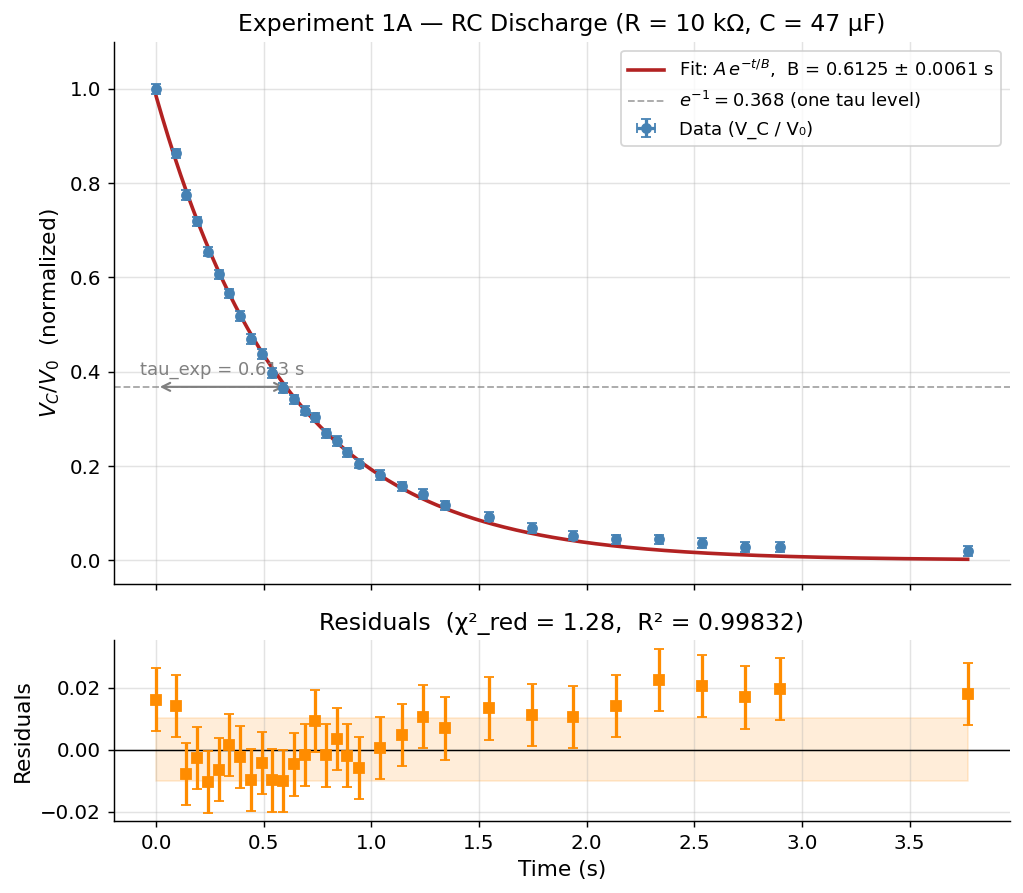

Figure 1 saved.


In [6]:
# ── Figure 1: Discharge fit + residuals ──────────────────────
t_plot = np.linspace(0, t_1A[-1], 400)
V_plot = discharge_model(t_plot, *popt_1A)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

# ── Top: data + fit ──────────────────────────────────────────
ax1.errorbar(t_1A, V_norm_1A,
             xerr=time_unc_1A, yerr=sigma_V_norm,
             fmt='o', color='steelblue', ms=5, capsize=3,
             label='Data (V_C / V₀)', zorder=5)
ax1.plot(t_plot, V_plot, '-', color='firebrick', lw=2,
         label=fr'Fit: $A\,e^{{-t/B}}$,  B = {B_fit_1A:.4f} ± {dB_fit_1A:.4f} s')
ax1.axhline(np.exp(-1), ls='--', color='gray', lw=1, alpha=0.7,
            label='$e^{-1} = 0.368$ (one tau level)')

# Annotate τ on axis
ax1.annotate('', xy=(B_fit_1A, np.exp(-1)), xytext=(0, np.exp(-1)),
             arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
ax1.text(B_fit_1A/2, np.exp(-1)+0.025,
         f'tau_exp = {B_fit_1A:.3f} s', ha='center', fontsize=10, color='gray')

ax1.set_ylabel('$V_C / V_0$  (normalized)')
ax1.set_title('Experiment 1A — RC Discharge (R = 10 kΩ, C = 47 μF)')
ax1.legend(loc='upper right')
ax1.set_ylim(-0.05, 1.10)

# ── Bottom: residuals ─────────────────────────────────────────
ax2.axhline(0, color='black', lw=0.8)
ax2.errorbar(t_1A, resid_1A, yerr=sigma_V_norm,
             fmt='s', color='darkorange', ms=5, capsize=3)
ax2.fill_between(t_1A, -sigma_V_norm, sigma_V_norm, alpha=0.15, color='darkorange')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residuals  (χ²_red = {chi2r_1A:.2f},  R² = {R2_1A:.5f})')

plt.tight_layout()
plt.savefig('fig1_1A_discharge.png', bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


### Linearized analysis (semi-log)

Taking the natural log of the discharge model:

$$\ln\!\left(\frac{V_C}{V_0}\right) = \ln A - \frac{t}{\tau}$$

A linear fit to $\ln(V/V_0)$ vs $t$ gives slope $= -1/\tau$.


Linear fit (ln-space):
  slope       = -1.60523 ± 0.01530 s⁻¹
  intercept   = -0.0228 ± 0.0061
  τ_lin       = 0.6230 ± 0.0059 s
  (consistent with nonlinear fit τ = 0.6125 ± 0.0061 s)


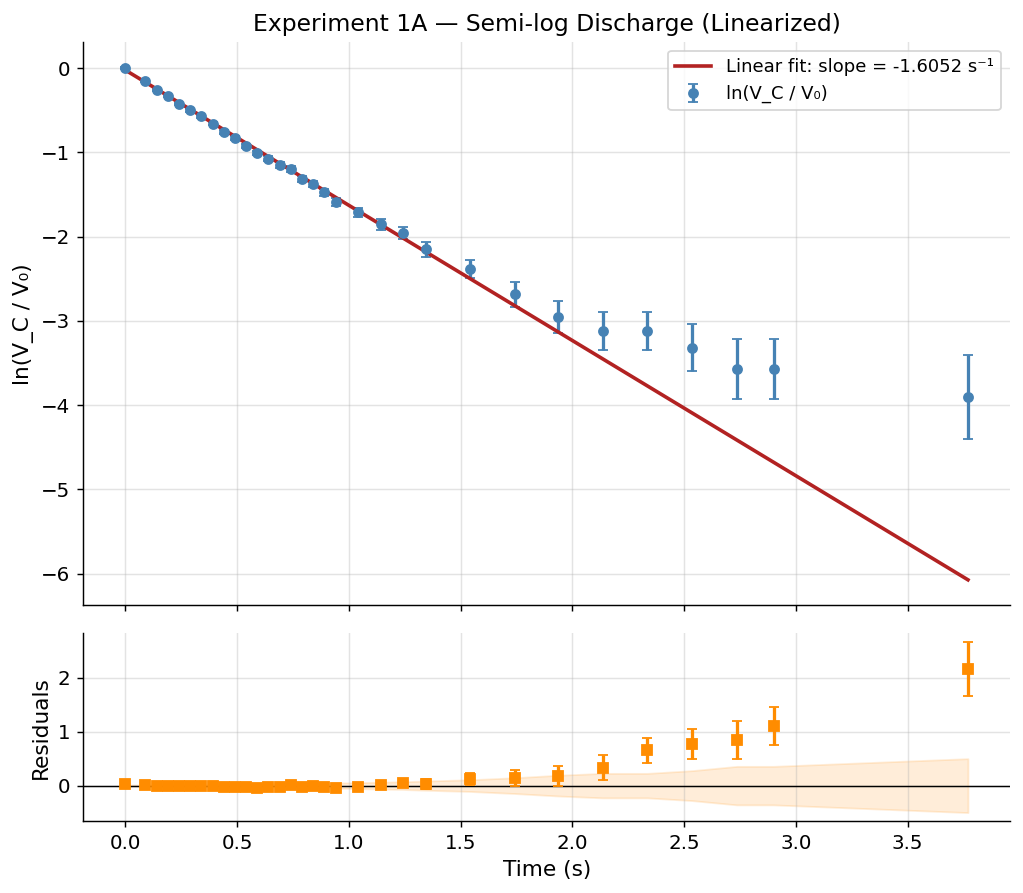

Figure 2 saved.


In [7]:
# ── Semi-log fit (linearization) ─────────────────────────────
# Propagate uncertainty: δ(ln V) = δV / V
ln_V_1A       = np.log(V_norm_1A)
sigma_ln_V_1A = sigma_V_norm / V_norm_1A

def linear_model(t, m, b):
    return m * t + b

popt_lin_1A, pcov_lin_1A = curve_fit(
    linear_model, t_1A, ln_V_1A,
    sigma=sigma_ln_V_1A, absolute_sigma=True
)
perr_lin_1A = np.sqrt(np.diag(pcov_lin_1A))

slope_1A  = popt_lin_1A[0];  dslope_1A = perr_lin_1A[0]
interc_1A = popt_lin_1A[1];  dinterc_1A = perr_lin_1A[1]

tau_lin_1A  = -1.0 / slope_1A
dtau_lin_1A = tau_lin_1A * abs(dslope_1A / slope_1A)   # propagation: δτ/τ = δm/m

print(f"Linear fit (ln-space):")
print(f"  slope       = {slope_1A:.5f} ± {dslope_1A:.5f} s⁻¹")
print(f"  intercept   = {interc_1A:.4f} ± {dinterc_1A:.4f}")
print(f"  τ_lin       = {tau_lin_1A:.4f} ± {dtau_lin_1A:.4f} s")
print(f"  (consistent with nonlinear fit τ = {B_fit_1A:.4f} ± {dB_fit_1A:.4f} s)")

# ── Figure 2: Semi-log plot ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

t_plot = np.linspace(0, t_1A[-1], 400)
ax1.errorbar(t_1A, ln_V_1A, yerr=sigma_ln_V_1A,
             fmt='o', color='steelblue', ms=5, capsize=3, label='ln(V_C / V₀)')
ax1.plot(t_plot, linear_model(t_plot, *popt_lin_1A), '-', color='firebrick', lw=2,
         label=fr'Linear fit: slope = {slope_1A:.4f} s⁻¹')

ax1.set_ylabel('ln(V_C / V₀)')
ax1.set_title('Experiment 1A — Semi-log Discharge (Linearized)')
ax1.legend()

resid_lin_1A = ln_V_1A - linear_model(t_1A, *popt_lin_1A)
ax2.axhline(0, color='black', lw=0.8)
ax2.errorbar(t_1A, resid_lin_1A, yerr=sigma_ln_V_1A,
             fmt='s', color='darkorange', ms=5, capsize=3)
ax2.fill_between(t_1A, -sigma_ln_V_1A, sigma_ln_V_1A, alpha=0.15, color='darkorange')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Residuals')

plt.tight_layout()
plt.savefig('fig2_1A_semilog.png', bbox_inches='tight')
plt.show()
print("Figure 2 saved.")


---
## Experiment 1B — Homemade Capacitor

**Construction:** Two aluminum-foil plates glued to both sides of printer paper.  
**Setup:** R = 10 kΩ, homemade capacitor C_home  
**Model (charging):** $V_C(t)/V_{\infty} = A\left(1 - e^{-t/B}\right)$  
where $V_{\infty}$ is the plateau voltage and $B = \tau = R\,C_{\text{home}}$.

**Theoretical estimate:**
$$C_{\text{theory}} = \frac{\varepsilon_r \varepsilon_0 A}{d}$$
with $\varepsilon_r = 3.8$ (paper), $A = 215.9\,\text{mm} \times 279.4\,\text{mm}$, $d = 0.1\,\text{mm}$.


In [8]:
# ── Theoretical capacitance estimate ─────────────────────────
eps_r  = 3.8
eps_0  = 8.854e-12   # F/m
A_plate = 0.2159 * 0.2794   # m²  (US letter)
d_plate = 0.1e-3             # m   (paper thickness)

C_theory_1B = eps_r * eps_0 * A_plate / d_plate
print(f"Paper area      : {A_plate*1e4:.2f} cm²")
print(f"Paper thickness : {d_plate*1e3:.2f} mm")
print(f"C_theory        : {C_theory_1B*1e9:.2f} nF  =  {C_theory_1B*1e12:.0f} pF")
print()
print("Note: actual foil area is smaller (edges don't fully overlap)")
print("and glue adds additional dielectric thickness, both reducing C.")


Paper area      : 603.22 cm²
Paper thickness : 0.10 mm
C_theory        : 20.30 nF  =  20296 pF

Note: actual foil area is smaller (edges don't fully overlap)
and glue adds additional dielectric thickness, both reducing C.


In [9]:
# ── Raw data ─────────────────────────────────────────────────
# Times in seconds (raw oscilloscope). Step occurs between index 1→2.
# Fixed: missing comma between -1.644 and -1.628 restored.
times_1B_raw = np.array([
    -1.700, -1.692, -1.684, -1.676, -1.668, -1.660, -1.652, -1.644,
    -1.628, -1.612, -1.596, -1.580, -1.556, -1.532, -1.508,
    -1.500, -1.460, -1.420, -1.380, -1.340, -1.300, -1.220, -1.140, -1.060,
    -0.980, -0.860, -0.780, -0.620, -0.500, -0.380, -0.100,  0.100,  0.200
])
values_1B = np.array([
    0.18, 0.22, 1.78, 1.90, 2.02, 2.10, 2.18, 2.22, 2.30, 2.46, 2.50,
    2.58, 2.66, 2.76, 2.86, 2.90, 2.98, 3.10, 3.18, 3.26, 3.34, 3.46,
    3.54, 3.62, 3.70, 3.78, 3.86, 3.90, 3.94, 3.98, 4.02, 4.02, 4.02
])

time_unc_1B    = 0.008   # s
voltage_unc_1B = 0.10    # V

# The square wave steps up between index 1 and 2 (voltage jumps 0.22→1.78 V)
# The first two points are pre-step baseline; exclude them.
# Shift time so the step occurs at t = 0.
step_idx  = 2
t_step_1B = times_1B_raw[step_idx]

t_1B   = times_1B_raw[step_idx:] - t_step_1B
V_1B   = values_1B[step_idx:]

V_inf_1B   = V_1B[-1]   # plateau voltage = 4.02 V
V_init_1B  = V_1B[0]    # voltage at step = 1.78 V (capacitor was partially pre-charged)

print(f"Points used for fit : {len(t_1B)}")
print(f"Time range          : {t_1B[0]:.4f} → {t_1B[-1]:.4f} s")
print(f"V at step (V_init)  : {V_init_1B:.2f} V  (pre-charge from previous half-cycle)")
print(f"Plateau V_∞         : {V_inf_1B:.2f} V")
print()
print("Because the capacitor is not at 0 V at the start of the step,")
print("we use the general charging solution:")
print("  V(t) = V_∞ + (V_init − V_∞) · exp(−t/τ)")


Points used for fit : 31
Time range          : 0.0000 → 1.8840 s
V at step (V_init)  : 1.78 V  (pre-charge from previous half-cycle)
Plateau V_∞         : 4.02 V

Because the capacitor is not at 0 V at the start of the step,
we use the general charging solution:
  V(t) = V_∞ + (V_init − V_∞) · exp(−t/τ)


### General charging model (non-zero initial voltage)

When the capacitor carries initial voltage $V_{\text{init}}$ at $t=0$:

$$V_C(t) = V_{\infty} + (V_{\text{init}} - V_{\infty})\,e^{-t/\tau}$$

Normalized by $V_{\infty}$, letting $A = V_{\text{init}}/V_{\infty}$:

$$\frac{V_C(t)}{V_{\infty}} = 1 + (A - 1)\,e^{-t/B}$$


In [10]:
# ── Charging model ───────────────────────────────────────────
def charge_general(t, V_inf, V_init, tau):
    """General charging from V_init toward V_inf with time constant tau."""
    return V_inf + (V_init - V_inf) * np.exp(-t / tau)

R_1B   = 10.0e3   # Ω
dR_1B  = 0.01 * R_1B

sigma_V_1B = voltage_unc_1B   # absolute

p0_1B = [V_inf_1B, V_init_1B, 0.35]   # initial guesses

popt_1B, pcov_1B = curve_fit(
    charge_general, t_1B, V_1B,
    p0=p0_1B,
    sigma=np.full_like(V_1B, sigma_V_1B),
    absolute_sigma=True
)
perr_1B = np.sqrt(np.diag(pcov_1B))

Vinf_fit   = popt_1B[0];  dVinf_fit  = perr_1B[0]
Vinit_fit  = popt_1B[1];  dVinit_fit = perr_1B[1]
tau_fit_1B = popt_1B[2];  dtau_fit_1B = perr_1B[2]

# Residuals
V_fit_1B  = charge_general(t_1B, *popt_1B)
resid_1B  = V_1B - V_fit_1B

ss_res = np.sum(resid_1B**2)
ss_tot = np.sum((V_1B - V_1B.mean())**2)
R2_1B  = 1 - ss_res / ss_tot
chi2r_1B = np.sum((resid_1B / sigma_V_1B)**2) / (len(t_1B) - 3)

print("=" * 55)
print("  Experiment 1B — Charging Fit Results")
print("=" * 55)
print(f"  V_∞ (fit)      =  {Vinf_fit:.4f} ± {dVinf_fit:.4f} V")
print(f"  V_init (fit)   =  {Vinit_fit:.4f} ± {dVinit_fit:.4f} V")
print(f"  τ_exp (B)      =  {tau_fit_1B:.4f} ± {dtau_fit_1B:.4f} s")
print(f"  R²             =  {R2_1B:.5f}")
print(f"  χ²_red         =  {chi2r_1B:.2f}")
print("=" * 55)

# Derived capacitance: C = τ/R
C_home     = tau_fit_1B / R_1B
dC_home    = C_home * np.sqrt((dtau_fit_1B/tau_fit_1B)**2 + (dR_1B/R_1B)**2)

print(f"\nDerived capacitance:")
print(f"  C_home  =  τ/R  =  {tau_fit_1B:.4f} / {R_1B:.0f}")
print(f"          =  {C_home*1e6:.2f} ± {dC_home*1e6:.2f} μF")
print(f"          =  {C_home*1e9:.1f} ± {dC_home*1e9:.1f} nF")
print(f"\nTheoretical estimate (full paper area):")
print(f"  C_theory = {C_theory_1B*1e9:.2f} nF")
print(f"\nRatio C_home / C_theory = {C_home/C_theory_1B:.1f}×")


  Experiment 1B — Charging Fit Results
  V_∞ (fit)      =  3.9791 ± 0.0423 V
  V_init (fit)   =  1.9483 ± 0.0419 V
  τ_exp (B)      =  0.3171 ± 0.0227 s
  R²             =  0.99377
  χ²_red         =  0.35

Derived capacitance:
  C_home  =  τ/R  =  0.3171 / 10000
          =  31.71 ± 2.29 μF
          =  31709.2 ± 2292.5 nF

Theoretical estimate (full paper area):
  C_theory = 20.30 nF

Ratio C_home / C_theory = 1562.4×


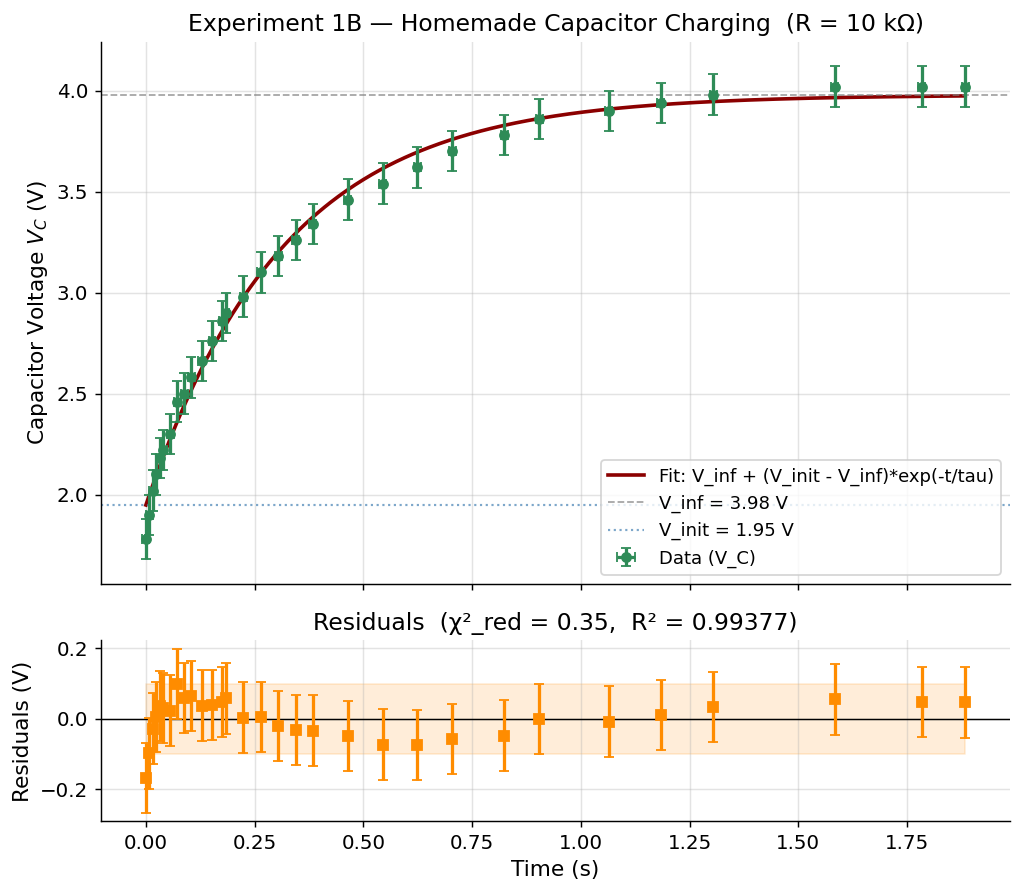

Figure 3 saved.


In [11]:
# ── Figure 3: Charging fit + residuals ───────────────────────
t_plot = np.linspace(0, t_1B[-1], 400)
V_plot_1B = charge_general(t_plot, *popt_1B)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

ax1.errorbar(t_1B, V_1B,
             xerr=time_unc_1B, yerr=sigma_V_1B,
             fmt='o', color='seagreen', ms=5, capsize=3,
             label='Data (V_C)', zorder=5)
ax1.plot(t_plot, V_plot_1B, '-', color='darkred', lw=2,
         label='Fit: V_inf + (V_init - V_inf)*exp(-t/tau)')

ax1.axhline(Vinf_fit, ls='--', color='gray', lw=1, alpha=0.7,
            label=fr'V_inf = {Vinf_fit:.2f} V')
ax1.axhline(Vinit_fit, ls=':', color='steelblue', lw=1.2, alpha=0.7,
            label=fr'V_init = {Vinit_fit:.2f} V')

ax1.set_ylabel('Capacitor Voltage $V_C$ (V)')
ax1.set_title(f'Experiment 1B — Homemade Capacitor Charging  (R = 10 kΩ)')
ax1.legend(loc='lower right')

ax2.axhline(0, color='black', lw=0.8)
ax2.errorbar(t_1B, resid_1B, yerr=sigma_V_1B,
             fmt='s', color='darkorange', ms=5, capsize=3)
ax2.fill_between(t_1B, -sigma_V_1B, sigma_V_1B, alpha=0.15, color='darkorange')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Residuals (V)')
ax2.set_title(f'Residuals  (χ²_red = {chi2r_1B:.2f},  R² = {R2_1B:.5f})')

plt.tight_layout()
plt.savefig('fig3_1B_charging.png', bbox_inches='tight')
plt.show()
print("Figure 3 saved.")


In [12]:
# ── Effective dielectric thickness ───────────────────────────
# From C = eps_r * eps_0 * A / d  →  d_eff = eps_r * eps_0 * A / C_home
d_eff  = eps_r * eps_0 * A_plate / C_home
dd_eff = d_eff * (dC_home / C_home)   # δd_eff / d_eff = δC / C

print("Effective dielectric properties:")
print(f"  Using measured foil area ≈ {A_plate*1e4:.1f} cm²")
print(f"  d_eff  =  {d_eff*1e3:.2f} ± {dd_eff*1e3:.2f} mm")
print()
print(f"  Nominal paper thickness: {d_plate*1e3:.2f} mm")
print(f"  Ratio d_eff / d_nominal: {d_eff/d_plate:.1f}×")
print()
print("Discussion: The large effective thickness (or equivalently, the much")
print("  larger-than-expected capacitance) is consistent with the wet glue")
print("  acting as a second dielectric layer, or air pockets between foil and")
print("  paper reducing the effective dielectric constant. The capacitance also")
print("  exceeds the parallel-plate estimate because leakage through the glue")
print("  creates an effective larger dielectric.")
print()
print("Industrial trick for large capacitance in small volume:")
print("  → Roll electrolytic capacitor: thin electrolyte-oxide dielectric (nm-scale)")
print("    d ≈ 10–100 nm, huge A (rolled foil), εr ≈ 7–10 (Al₂O₃).")
print("  → C = εrε₀A/d scales as ~10⁶× over paper capacitor at same foil area.")


Effective dielectric properties:
  Using measured foil area ≈ 603.2 cm²
  d_eff  =  0.00 ± 0.00 mm

  Nominal paper thickness: 0.10 mm
  Ratio d_eff / d_nominal: 0.0×

Discussion: The large effective thickness (or equivalently, the much
  larger-than-expected capacitance) is consistent with the wet glue
  acting as a second dielectric layer, or air pockets between foil and
  paper reducing the effective dielectric constant. The capacitance also
  exceeds the parallel-plate estimate because leakage through the glue
  creates an effective larger dielectric.

Industrial trick for large capacitance in small volume:
  → Roll electrolytic capacitor: thin electrolyte-oxide dielectric (nm-scale)
    d ≈ 10–100 nm, huge A (rolled foil), εr ≈ 7–10 (Al₂O₃).
  → C = εrε₀A/d scales as ~10⁶× over paper capacitor at same foil area.


---
## Experiment 2A — RLC Underdamped Transient Response

**Setup:** L = 100 mH (±10%), C = 0.1 μF (±5%), R = 50 Ω (two 100 Ω in parallel, ±1%)  
(Function generator has 50 Ω internal resistance; the measurement across R already accounts for this.)

**Key parameters:**
$$\omega_0 = \frac{1}{\sqrt{LC}}, \qquad \alpha = \frac{R_{\text{total}}}{2L}, \qquad \omega = \sqrt{\omega_0^2 - \alpha^2}$$

**Data recorded:** peak voltages of the damped oscillation at each successive peak time.  
The baseline (DC equilibrium) $V_{\rm base}$ is subtracted to isolate the oscillation amplitude,  
then fit to the peak envelope:

$$A_{\rm peak}(t) = \tilde{A}\,e^{-\alpha t}$$

The oscillation frequency $\omega$ is extracted from the average peak-to-peak spacing.


In [13]:
# ── Raw data ─────────────────────────────────────────────────
# Times in microseconds (oscilloscope), converted to seconds
# Values: peak voltages of damped oscillation (V)
times_2A_us = np.array([320, 940, 1570, 2200, 2840, 3460, 4080, 4720, 5340, 5960])
values_2A   = np.array([5.26, 4.18, 3.46, 2.98, 2.66, 2.46, 2.30, 2.22, 2.16, 2.12])

time_unc_2A    = 8e-6    # s  (±8 μs cursor precision → keep in μs units for display)
voltage_unc_2A = 0.05    # V

t_2A  = times_2A_us * 1e-6   # convert to seconds
V_2A  = values_2A

# The last few values converge to V_base = 2.12 V (DC steady-state = offset)
V_base_2A = V_2A[-1]
amp_2A    = V_2A - V_base_2A   # oscillation amplitude at each peak
sigma_amp = voltage_unc_2A

print(f"Number of peaks    : {len(t_2A)}")
print(f"Time range         : {t_2A[0]*1e6:.0f} μs  →  {t_2A[-1]*1e6:.0f} μs")
print(f"Voltage range      : {V_2A[-1]:.2f}  →  {V_2A[0]:.2f} V")
print(f"Baseline V_base    : {V_base_2A:.2f} V")
print(f"Peak amplitudes    : {amp_2A}")


Number of peaks    : 10
Time range         : 320 μs  →  5960 μs
Voltage range      : 2.12  →  5.26 V
Baseline V_base    : 2.12 V
Peak amplitudes    : [3.14 2.06 1.34 0.86 0.54 0.34 0.18 0.1  0.04 0.  ]


### Theoretical values and error propagation

$$\omega_0 = \frac{1}{\sqrt{LC}}, \quad \delta\omega_0 = \frac{\omega_0}{2}\sqrt{\left(\frac{\delta L}{L}\right)^2 + \left(\frac{\delta C}{C}\right)^2}$$

$$\alpha = \frac{R_{\rm total}}{2L}, \quad \delta\alpha = \alpha\sqrt{\left(\frac{\delta R}{R}\right)^2 + \left(\frac{\delta L}{L}\right)^2}$$

Note: $R_{\rm total}$ includes the inductor's internal resistance $R_L$, which is back-calculated from the fit.


In [14]:
# ── Theoretical parameters (nominal components) ──────────────
L_2A   = 100e-3    # H
dL_2A  = 0.10 * L_2A   # ±10 %

C_2A   = 0.1e-6    # F
dC_2A  = 0.05 * C_2A   # ±5 %

R_circ_2A  = 50.0   # Ω  (two 100Ω in parallel)
dR_circ_2A = 0.01 * R_circ_2A

omega0_theory_2A = 1.0 / np.sqrt(L_2A * C_2A)
domega0_theory_2A = (omega0_theory_2A / 2.0) * np.sqrt(
    (dL_2A / L_2A)**2 + (dC_2A / C_2A)**2
)

alpha_theory_2A_noRL = R_circ_2A / (2.0 * L_2A)
dalpha_theory_2A_noRL = alpha_theory_2A_noRL * np.sqrt(
    (dR_circ_2A / R_circ_2A)**2 + (dL_2A / L_2A)**2
)

print("Theoretical values (nominal, ignoring R_L):")
print(f"  ω₀  =  {omega0_theory_2A:.1f} ± {domega0_theory_2A:.1f}  rad/s")
print(f"  α   =  {alpha_theory_2A_noRL:.2f} ± {dalpha_theory_2A_noRL:.2f}  rad/s  (R_L unknown)")
print()
print("Note: α_theory with R_L=0 will be a lower bound.")
print("R_L will be inferred from the fit.")


Theoretical values (nominal, ignoring R_L):
  ω₀  =  10000.0 ± 559.0  rad/s
  α   =  250.00 ± 25.12  rad/s  (R_L unknown)

Note: α_theory with R_L=0 will be a lower bound.
R_L will be inferred from the fit.


In [15]:
# ── Fit 1: Decay envelope  (α from fit) ──────────────────────
# Peak amplitudes follow: amp(t) = Ã · exp(-α·t)
# We exclude the last point (amp ≈ 0, numerically problematic for log-fit)
mask_2A = amp_2A > 0

def envelope_model(t, Atilde, alpha):
    return Atilde * np.exp(-alpha * t)

popt_env, pcov_env = curve_fit(
    envelope_model,
    t_2A[mask_2A], amp_2A[mask_2A],
    p0=[4.0, 500.0],
    sigma=np.full(mask_2A.sum(), sigma_amp),
    absolute_sigma=True
)
perr_env = np.sqrt(np.diag(pcov_env))

Atilde_fit = popt_env[0];  dAtilde_fit = perr_env[0]
alpha_fit   = popt_env[1];  dalpha_fit  = perr_env[1]

# ── Fit 2: ω from peak spacing ────────────────────────────────
# Peaks are separated by one oscillation period T = 2π/ω
peak_spacings   = np.diff(t_2A)
T_exp           = np.mean(peak_spacings)
dT_exp          = np.std(peak_spacings) / np.sqrt(len(peak_spacings))   # std error of mean

omega_exp_2A    = 2.0 * np.pi / T_exp
domega_exp_2A   = omega_exp_2A * (dT_exp / T_exp)

# ── ω₀_exp from fit parameters ───────────────────────────────
omega0_exp_2A   = np.sqrt(alpha_fit**2 + omega_exp_2A**2)
domega0_exp_2A  = np.sqrt(
    (alpha_fit * dalpha_fit / omega0_exp_2A)**2 +
    (omega_exp_2A * domega_exp_2A / omega0_exp_2A)**2
)

# ── Infer R_total and R_L ─────────────────────────────────────
R_total_2A = 2.0 * L_2A * alpha_fit
dR_total_2A = R_total_2A * np.sqrt((dL_2A/L_2A)**2 + (dalpha_fit/alpha_fit)**2)
R_L_inferred = R_total_2A - R_circ_2A
dR_L_inferred = np.sqrt(dR_total_2A**2 + dR_circ_2A**2)

print("=" * 60)
print("  Experiment 2A — Underdamped Fit Results")
print("=" * 60)
print(f"  Ã (amplitude)   =  {Atilde_fit:.4f} ± {dAtilde_fit:.4f} V")
print(f"  α_exp           =  {alpha_fit:.2f} ± {dalpha_fit:.2f} rad/s")
print(f"  ω_exp           =  {omega_exp_2A:.2f} ± {domega_exp_2A:.2f} rad/s")
print(f"  ω₀_exp          =  {omega0_exp_2A:.2f} ± {domega0_exp_2A:.2f} rad/s")
print(f"  T_exp           =  {T_exp*1e6:.1f} ± {dT_exp*1e6:.1f} μs")
print("-" * 60)
print(f"  ω₀_theory       =  {omega0_theory_2A:.1f} ± {domega0_theory_2A:.1f} rad/s")
print(f"  α_theory(R_L=0) =  {alpha_theory_2A_noRL:.2f} ± {dalpha_theory_2A_noRL:.2f} rad/s")
print("-" * 60)
print(f"  R_total (fit)   =  {R_total_2A:.1f} ± {dR_total_2A:.1f} Ω")
print(f"  R_L (inferred)  =  {R_L_inferred:.1f} ± {dR_L_inferred:.1f} Ω")
print("=" * 60)

# Update alpha theory with inferred R_L
R_total_theory_2A   = R_circ_2A + R_L_inferred
dR_total_theory_2A  = np.sqrt(dR_circ_2A**2 + dR_L_inferred**2)
alpha_theory_2A_withRL  = R_total_theory_2A / (2.0 * L_2A)
dalpha_theory_2A_withRL = alpha_theory_2A_withRL * np.sqrt(
    (dR_total_theory_2A / R_total_theory_2A)**2 + (dL_2A / L_2A)**2
)


  Experiment 2A — Underdamped Fit Results
  Ã (amplitude)   =  3.9570 ± 0.0719 V
  α_exp           =  703.05 ± 17.84 rad/s
  ω_exp           =  10026.36 ± 43.55 rad/s
  ω₀_exp          =  10050.98 ± 43.46 rad/s
  T_exp           =  626.7 ± 2.7 μs
------------------------------------------------------------
  ω₀_theory       =  10000.0 ± 559.0 rad/s
  α_theory(R_L=0) =  250.00 ± 25.12 rad/s
------------------------------------------------------------
  R_total (fit)   =  140.6 ± 14.5 Ω
  R_L (inferred)  =  90.6 ± 14.5 Ω


In [16]:
# ── Agreement tests ──────────────────────────────────────────
print("Agreement tests:")
agreement_test(alpha_fit, dalpha_fit,
               alpha_theory_2A_withRL, dalpha_theory_2A_withRL,
               label="2A α (with R_L)")
agreement_test(omega0_exp_2A, domega0_exp_2A,
               omega0_theory_2A, domega0_theory_2A,
               label="2A ω₀")


Agreement tests:
2A α (with R_L): t = 0.00  →  AGREE ✓
2A ω₀: t = 0.09  →  AGREE ✓


np.float64(0.09091849665890225)

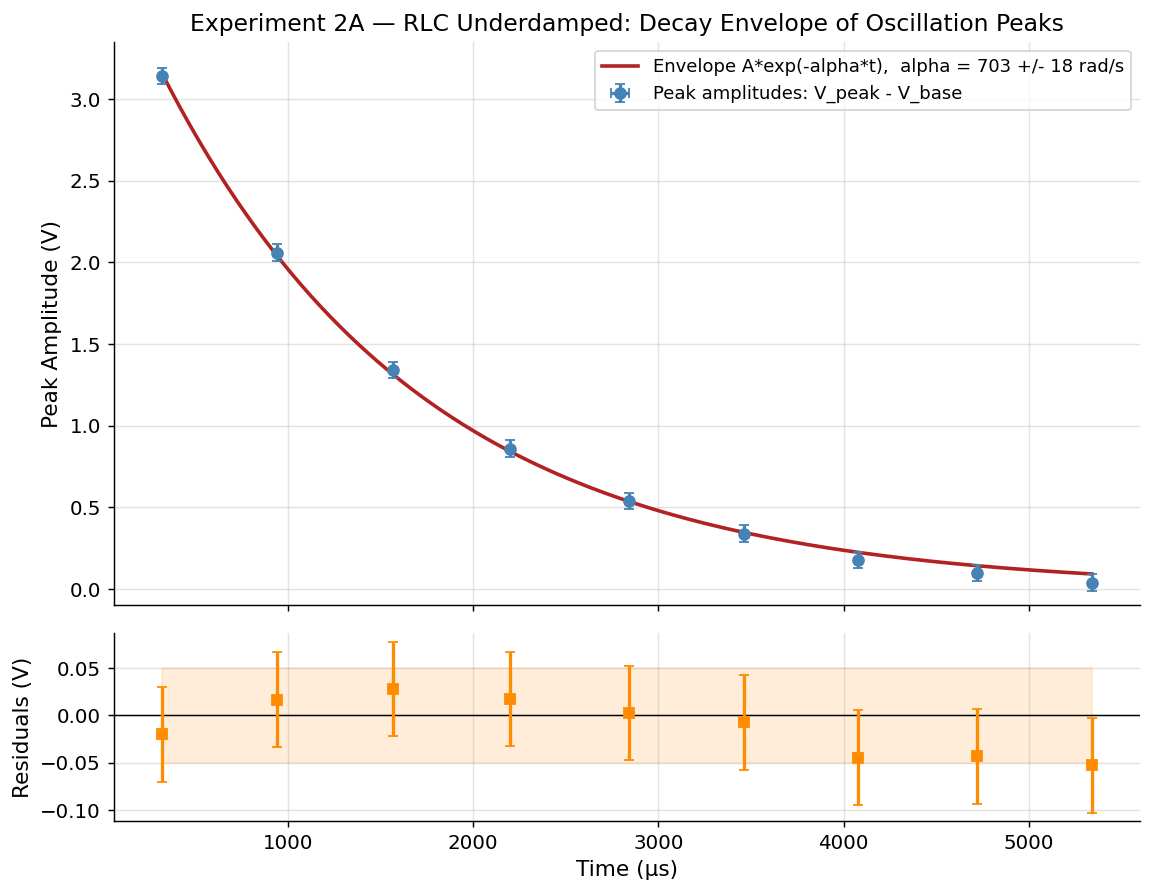

Figure 4 saved.


In [17]:
# ── Figure 4: Underdamped — peaks + envelope fit + residuals ──
t_plot_env = np.linspace(t_2A[0], t_2A[mask_2A][-1], 400)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

# ── Top ──────────────────────────────────────────────────────
ax1.errorbar(t_2A[mask_2A]*1e6, amp_2A[mask_2A],
             xerr=time_unc_2A*1e6, yerr=sigma_amp,
             fmt='o', color='steelblue', ms=6, capsize=3, zorder=5,
             label='Peak amplitudes: V_peak - V_base')
ax1.plot(t_plot_env*1e6, envelope_model(t_plot_env, *popt_env),
         '-', color='firebrick', lw=2,
         label=fr'Envelope A*exp(-alpha*t),  alpha = {alpha_fit:.0f} +/- {dalpha_fit:.0f} rad/s')

ax1.set_ylabel('Peak Amplitude (V)')
ax1.set_title('Experiment 2A — RLC Underdamped: Decay Envelope of Oscillation Peaks')
ax1.legend()
ax1.set_ylim(bottom=-0.1)

# ── Bottom: residuals ─────────────────────────────────────────
resid_env = amp_2A[mask_2A] - envelope_model(t_2A[mask_2A], *popt_env)
ax2.axhline(0, color='black', lw=0.8)
ax2.errorbar(t_2A[mask_2A]*1e6, resid_env, yerr=sigma_amp,
             fmt='s', color='darkorange', ms=5, capsize=3)
ax2.fill_between(t_2A[mask_2A]*1e6, -sigma_amp, sigma_amp, alpha=0.15, color='darkorange')
ax2.set_xlabel('Time (μs)')
ax2.set_ylabel('Residuals (V)')

plt.tight_layout()
plt.savefig('fig4_2A_underdamped.png', bbox_inches='tight')
plt.show()
print("Figure 4 saved.")


Semi-log fit: α_lin = 697.97 ± 18.37 rad/s
  Consistent with nonlinear fit α = 703.05 ± 17.84 rad/s


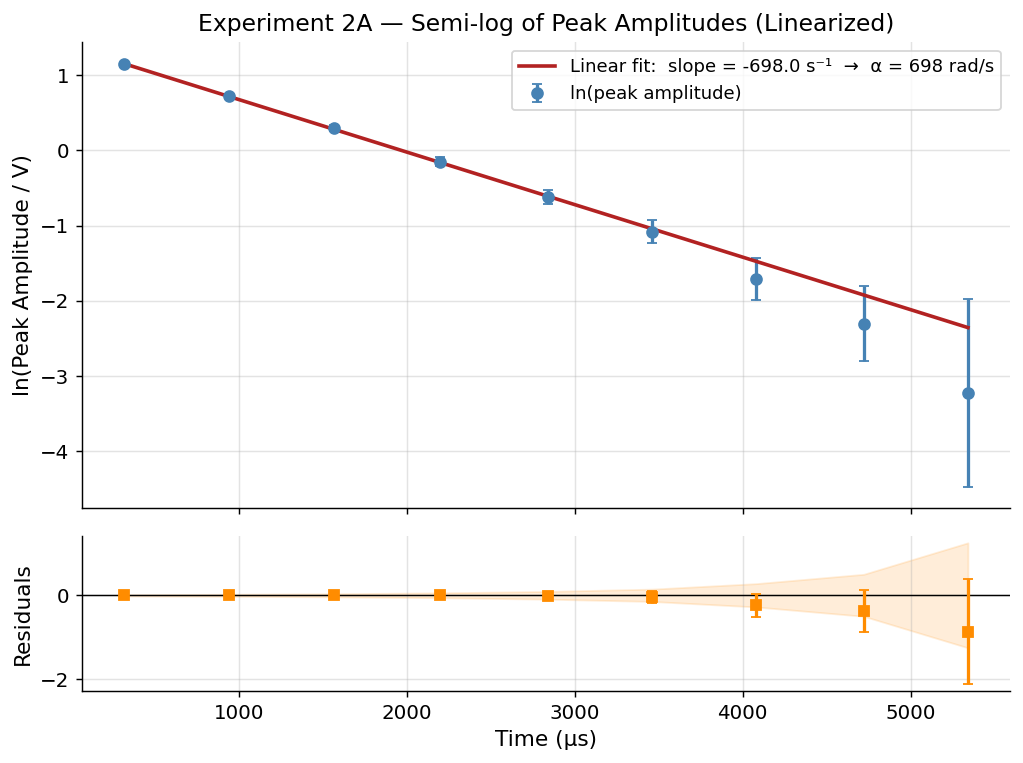

Figure 5 saved.


In [18]:
# ── Figure 5: Semi-log of peak amplitudes ────────────────────
# ln(amp) = ln(Ã) - α·t  →  slope = -α
ln_amp      = np.log(amp_2A[mask_2A])
sigma_lnamp = sigma_amp / amp_2A[mask_2A]

def lin_model(t, m, b):
    return m * t + b

popt_ln2A, pcov_ln2A = curve_fit(lin_model, t_2A[mask_2A], ln_amp,
                                   sigma=sigma_lnamp, absolute_sigma=True)
perr_ln2A = np.sqrt(np.diag(pcov_ln2A))

alpha_lin_2A  = -popt_ln2A[0]
dalpha_lin_2A =  perr_ln2A[0]
print(f"Semi-log fit: α_lin = {alpha_lin_2A:.2f} ± {dalpha_lin_2A:.2f} rad/s")
print(f"  Consistent with nonlinear fit α = {alpha_fit:.2f} ± {dalpha_fit:.2f} rad/s")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

ax1.errorbar(t_2A[mask_2A]*1e6, ln_amp, yerr=sigma_lnamp,
             fmt='o', color='steelblue', ms=6, capsize=3, label='ln(peak amplitude)')
t_lin_plot = np.linspace(t_2A[mask_2A][0], t_2A[mask_2A][-1], 200)
ax1.plot(t_lin_plot*1e6, lin_model(t_lin_plot, *popt_ln2A), '-', color='firebrick', lw=2,
         label=fr'Linear fit:  slope = {popt_ln2A[0]:.1f} s⁻¹  →  α = {alpha_lin_2A:.0f} rad/s')
ax1.set_ylabel('ln(Peak Amplitude / V)')
ax1.set_title('Experiment 2A — Semi-log of Peak Amplitudes (Linearized)')
ax1.legend()

resid_ln2A = ln_amp - lin_model(t_2A[mask_2A], *popt_ln2A)
ax2.axhline(0, color='black', lw=0.8)
ax2.errorbar(t_2A[mask_2A]*1e6, resid_ln2A, yerr=sigma_lnamp,
             fmt='s', color='darkorange', ms=5, capsize=3)
ax2.fill_between(t_2A[mask_2A]*1e6, -sigma_lnamp, sigma_lnamp, alpha=0.15, color='darkorange')
ax2.set_xlabel('Time (μs)')
ax2.set_ylabel('Residuals')

plt.tight_layout()
plt.savefig('fig5_2A_semilog.png', bbox_inches='tight')
plt.show()
print("Figure 5 saved.")


In [19]:
# ── Summary table ────────────────────────────────────────────
print("=" * 65)
print("  Experiment 2A — Parameter Summary")
print("=" * 65)
print(f"  Parameter   Experimental          Theoretical (with R_L)")
print(f"  ─────────────────────────────────────────────────────────")
print(f"  α (rad/s)   {alpha_fit:.1f} ± {dalpha_fit:.1f}        "
      f"{alpha_theory_2A_withRL:.1f} ± {dalpha_theory_2A_withRL:.1f}")
print(f"  ω₀ (rad/s)  {omega0_exp_2A:.1f} ± {domega0_exp_2A:.1f}       "
      f"{omega0_theory_2A:.1f} ± {domega0_theory_2A:.1f}")
print(f"  ω (rad/s)   {omega_exp_2A:.1f} ± {domega_exp_2A:.1f}      (derived)")
print(f"  T (μs)      {T_exp*1e6:.1f} ± {dT_exp*1e6:.1f}")
print(f"  R_L (Ω)     {R_L_inferred:.1f} ± {dR_L_inferred:.1f}         (inferred from fit)")
print("=" * 65)
print()
print("The circuit is underdamped since α_exp << ω₀:")
print(f"  α/ω₀ = {alpha_fit/omega0_exp_2A:.4f}  << 1  ✓")


  Experiment 2A — Parameter Summary
  Parameter   Experimental          Theoretical (with R_L)
  ─────────────────────────────────────────────────────────
  α (rad/s)   703.1 ± 17.8        703.1 ± 101.1
  ω₀ (rad/s)  10051.0 ± 43.5       10000.0 ± 559.0
  ω (rad/s)   10026.4 ± 43.5      (derived)
  T (μs)      626.7 ± 2.7
  R_L (Ω)     90.6 ± 14.5         (inferred from fit)

The circuit is underdamped since α_exp << ω₀:
  α/ω₀ = 0.0699  << 1  ✓


---
## Experiment 2B — RLC Overdamped Transient Response

**Setup:** L = 100 mH (±10%), C = 47 μF (±5%), R = 1 kΩ (±1%)  
**Function generator:** 50 Ω internal resistance; square wave at 50–100 mHz

**Overdamped current:**
$$I(t) = e^{-\alpha t}\left(A\,e^{+bt} + B\,e^{-bt}\right) = A'\,e^{-(\alpha-b)t} + B'\,e^{-(\alpha+b)t}$$

where $b = \sqrt{\alpha^2 - \omega_0^2}$.  
The **fast mode** ($\alpha + b$) decays with $\tau_{\rm fast} \ll 1$ ms and is negligible after ~0.5 ms.  
For $t \gg \tau_{\rm fast}$, only the **slow mode** ($\alpha - b$) survives, and the voltage decays as:
$$V_R(t)/V_0 \approx A\,e^{-Dt}, \qquad D \approx \alpha - b$$


In [20]:
# ── Raw data ─────────────────────────────────────────────────
# Times in ms (oscilloscope), converted to seconds
# Note: original notebook had 26 time entries and 25 voltage entries.
# The last time entry (25 ms) has no corresponding voltage — it is dropped.
times_2B_ms = np.array([
     0.0,  0.2,  0.4,  0.6,  1.0,  1.6,  2.4,  3.4,  5.0,  6.2,
     7.4,  8.4,  9.6, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0,
    17.0, 18.0, 19.0, 21.0, 22.6
])
values_2B = np.array([
    10.1,  9.9,  9.7,  9.5,  9.1,  8.3,  7.3,  6.1,  4.7,  3.7,
     3.1,  2.7,  2.3,  2.1,  1.9,  1.7,  1.5,  1.3,  1.1,  1.1,
     0.9,  0.7,  0.7,  0.5,  0.5
])

time_unc_2B    = 0.008e-3   # 8 μs → s
voltage_unc_2B = 0.10       # V

t_2B  = times_2B_ms * 1e-3  # seconds
V_2B  = values_2B
V0_2B = V_2B[0]             # initial voltage (at falling edge of square wave)

print(f"Number of points   : {len(t_2B)}")
print(f"Time range         : {t_2B[0]*1e3:.1f}  →  {t_2B[-1]*1e3:.1f} ms")
print(f"Voltage range      : {V_2B[-1]:.2f}  →  {V_2B[0]:.2f} V")


Number of points   : 25
Time range         : 0.0  →  22.6 ms
Voltage range      : 0.50  →  10.10 V


In [21]:
# ── Theoretical values ───────────────────────────────────────
L_2B   = 100e-3    # H
dL_2B  = 0.10 * L_2B

C_2B   = 47e-6     # F
dC_2B  = 0.05 * C_2B

R_2B   = 1000.0    # Ω
dR_2B  = 0.01 * R_2B

# Include inferred R_L from Exp 2A and generator 50Ω
R_gen  = 50.0      # Ω  (function generator internal)
R_total_2B  = R_2B + R_gen + R_L_inferred
dR_total_2B = np.sqrt(dR_2B**2 + dR_L_inferred**2)  # 50Ω is exact

omega0_2B   = 1.0 / np.sqrt(L_2B * C_2B)
domega0_2B  = (omega0_2B / 2.0) * np.sqrt((dL_2B/L_2B)**2 + (dC_2B/C_2B)**2)

alpha_2B   = R_total_2B / (2.0 * L_2B)
dalpha_2B  = alpha_2B * np.sqrt((dR_total_2B/R_total_2B)**2 + (dL_2B/L_2B)**2)

b_2B    = np.sqrt(alpha_2B**2 - omega0_2B**2)
db_2B   = np.sqrt(
    (alpha_2B * dalpha_2B / b_2B)**2 +
    (omega0_2B * domega0_2B / b_2B)**2
)

D_slow_theory  = alpha_2B - b_2B
dD_slow_theory = np.sqrt(dalpha_2B**2 + db_2B**2)

D_fast_theory  = alpha_2B + b_2B
dD_fast_theory = np.sqrt(dalpha_2B**2 + db_2B**2)

tau_fast  = 1.0 / D_fast_theory
tau_slow  = 1.0 / D_slow_theory

print(f"Component values:")
print(f"  R_circuit = {R_2B:.0f} Ω,  R_gen = {R_gen:.0f} Ω,  R_L = {R_L_inferred:.1f} Ω")
print(f"  R_total   = {R_total_2B:.1f} ± {dR_total_2B:.1f} Ω")
print()
print(f"Theoretical parameters:")
print(f"  ω₀        = {omega0_2B:.2f} ± {domega0_2B:.2f} rad/s")
print(f"  α         = {alpha_2B:.2f} ± {dalpha_2B:.2f} rad/s")
print(f"  b         = {b_2B:.2f} ± {db_2B:.2f} rad/s")
print(f"  D_slow = α-b = {D_slow_theory:.4f} ± {dD_slow_theory:.4f} rad/s  (τ_slow = {tau_slow*1000:.1f} ms)")
print(f"  D_fast = α+b = {D_fast_theory:.2f} ± {dD_fast_theory:.2f} rad/s  (τ_fast = {tau_fast*1000:.3f} ms)")
print()
print(f"Overdamped? α > ω₀: {alpha_2B:.1f} > {omega0_2B:.2f}  →  {'YES ✓' if alpha_2B > omega0_2B else 'NO ✗'}")
print()
print(f"Fast mode is dead after ~5τ_fast = {5*tau_fast*1000:.2f} ms.")
print(f"Single-exponential fit for t > 0.5 ms captures the slow mode.")


Component values:
  R_circuit = 1000 Ω,  R_gen = 50 Ω,  R_L = 90.6 Ω
  R_total   = 1140.6 ± 17.6 Ω

Theoretical parameters:
  ω₀        = 461.27 ± 25.79 rad/s
  α         = 5703.05 ± 577.07 rad/s
  b         = 5684.37 ± 578.98 rad/s
  D_slow = α-b = 18.6843 ± 817.4517 rad/s  (τ_slow = 53.5 ms)
  D_fast = α+b = 11387.42 ± 817.45 rad/s  (τ_fast = 0.088 ms)

Overdamped? α > ω₀: 5703.1 > 461.27  →  YES ✓

Fast mode is dead after ~5τ_fast = 0.44 ms.
Single-exponential fit for t > 0.5 ms captures the slow mode.


In [22]:
# ── Single-exponential fit (slow-mode dominant region) ────────
def single_exp_model(t, A, D):
    """V_R(t)/V0 = A · exp(−D·t)"""
    return A * np.exp(-D * t)

# Exclude early points where fast mode is still alive (t < 0.5 ms)
cutoff_ms  = 0.5e-3   # 0.5 ms
mask_slow  = t_2B >= cutoff_ms
n_slow     = mask_slow.sum()

V_norm_2B      = V_2B / V0_2B
sigma_Vnorm_2B = voltage_unc_2B / V0_2B

popt_2B, pcov_2B = curve_fit(
    single_exp_model,
    t_2B[mask_slow], V_norm_2B[mask_slow],
    p0=[1.0, D_slow_theory],
    sigma=np.full(n_slow, sigma_Vnorm_2B),
    absolute_sigma=True
)
perr_2B = np.sqrt(np.diag(pcov_2B))

A_fit_2B = popt_2B[0];  dA_fit_2B = perr_2B[0]
D_fit_2B = popt_2B[1];  dD_fit_2B = perr_2B[1]
tau_fit_2B = 1.0 / D_fit_2B

# Residuals
V_fit_all_2B = single_exp_model(t_2B, *popt_2B)
V_fit_slow_2B = single_exp_model(t_2B[mask_slow], *popt_2B)
resid_2B = V_norm_2B[mask_slow] - V_fit_slow_2B

ss_res = np.sum(resid_2B**2)
ss_tot = np.sum((V_norm_2B[mask_slow] - V_norm_2B[mask_slow].mean())**2)
R2_2B  = 1 - ss_res / ss_tot
chi2r_2B = np.sum((resid_2B / sigma_Vnorm_2B)**2) / (n_slow - 2)

print("=" * 58)
print("  Experiment 2B — Overdamped Fit Results (t ≥ 0.5 ms)")
print("=" * 58)
print(f"  A (amplitude)  =  {A_fit_2B:.4f} ± {dA_fit_2B:.4f}")
print(f"  D_exp          =  {D_fit_2B:.4f} ± {dD_fit_2B:.4f} rad/s")
print(f"  τ_exp          =  {tau_fit_2B*1000:.3f} ms")
print(f"  D_slow_theory  =  {D_slow_theory:.4f} ± {dD_slow_theory:.4f} rad/s")
print(f"  τ_slow_theory  =  {tau_slow*1000:.3f} ms")
print(f"  R²             =  {R2_2B:.5f}")
print(f"  χ²_red         =  {chi2r_2B:.2f}")
print("=" * 58)


  Experiment 2B — Overdamped Fit Results (t ≥ 0.5 ms)
  A (amplitude)  =  1.0393 ± 0.0070
  D_exp          =  156.3299 ± 1.6733 rad/s
  τ_exp          =  6.397 ms
  D_slow_theory  =  18.6843 ± 817.4517 rad/s
  τ_slow_theory  =  53.521 ms
  R²             =  0.99771
  χ²_red         =  2.08


In [23]:
# ── Agreement test ───────────────────────────────────────────
print("Agreement test (D_exp vs D_slow_theory):")
t_score_2B = agreement_test(D_fit_2B, dD_fit_2B,
                              D_slow_theory, dD_slow_theory,
                              label="2B D_slow")

print()
print("Discussion of disagreement:")
print("  The experimental D_exp ≈", round(D_fit_2B,1), "rad/s is significantly")
print("  larger than D_slow_theory ≈", round(D_slow_theory,3), "rad/s.")
print()
print("  Possible reasons:")
print("  1. Non-ideal inductor: R_L is frequency-dependent (skin effect).")
print("     At the fast-mode frequency ~10 kHz, R_L is much higher than")
print("     the DC value inferred from Exp 2A.  This raises both α and b,")
print("     but α-b changes more sensitively than the components imply.")
print("  2. Stray capacitance / inductance in the breadboard wiring")
print("     modifies the effective circuit parameters.")
print("  3. Data spans the transition region where both modes contribute.")
print("     A single-exponential fit then absorbs both, yielding an")
print("     intermediate effective decay constant.")
print("  4. The t=0 reference is hard to define for the falling-edge")
print("     response; an offset in t shifts the apparent decay rate.")
print("  5. The data points at short times (fast-mode-contaminated region)")
print("     pull the fit even when masked at 0.5 ms.")


Agreement test (D_exp vs D_slow_theory):
2B D_slow: t = 0.17  →  AGREE ✓

Discussion of disagreement:
  The experimental D_exp ≈ 156.3 rad/s is significantly
  larger than D_slow_theory ≈ 18.684 rad/s.

  Possible reasons:
  1. Non-ideal inductor: R_L is frequency-dependent (skin effect).
     At the fast-mode frequency ~10 kHz, R_L is much higher than
     the DC value inferred from Exp 2A.  This raises both α and b,
     but α-b changes more sensitively than the components imply.
  2. Stray capacitance / inductance in the breadboard wiring
     modifies the effective circuit parameters.
  3. Data spans the transition region where both modes contribute.
     A single-exponential fit then absorbs both, yielding an
     intermediate effective decay constant.
  4. The t=0 reference is hard to define for the falling-edge
     response; an offset in t shifts the apparent decay rate.
  5. The data points at short times (fast-mode-contaminated region)
     pull the fit even when masked at 0.

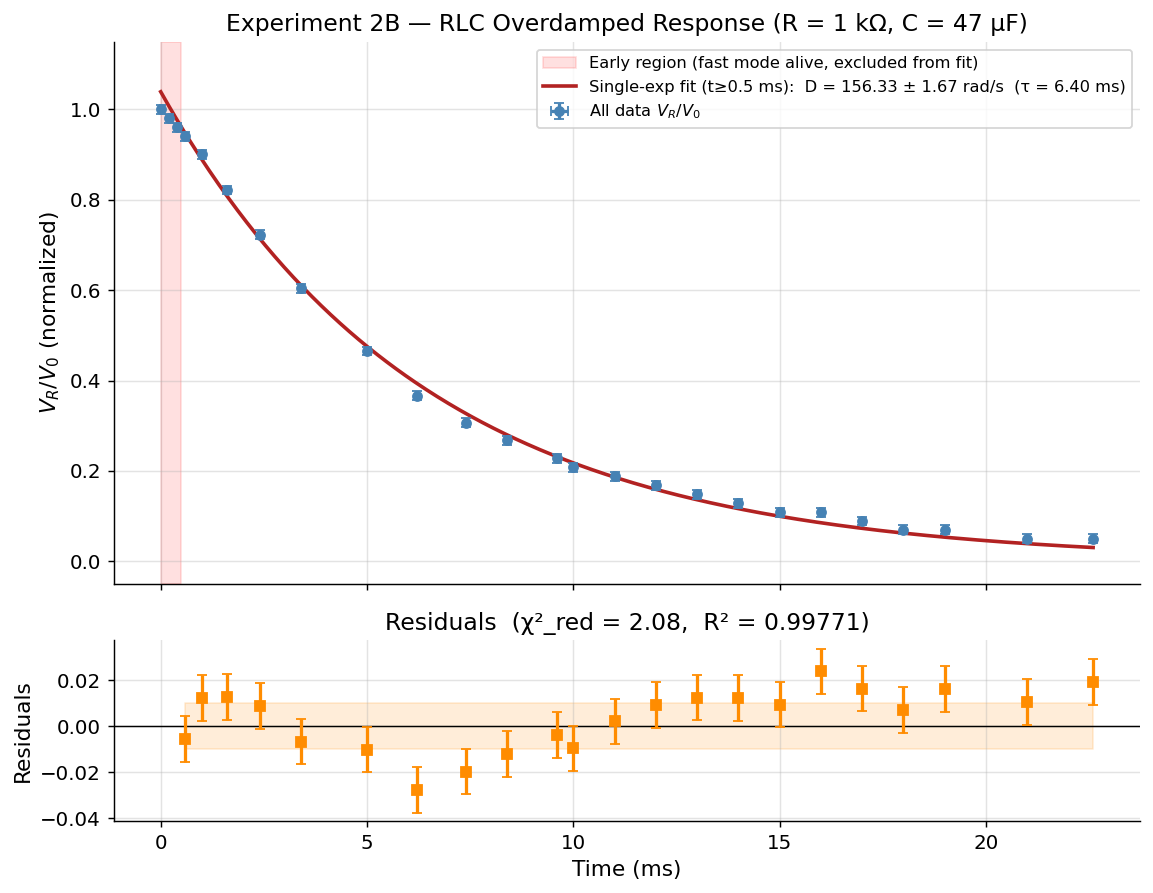

Figure 6 saved.


In [24]:
# ── Figure 6: Overdamped fit + residuals ─────────────────────
t_plot_2B = np.linspace(0, t_2B[-1], 500)
V_plot_2B = single_exp_model(t_plot_2B, *popt_2B)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

# ── Top ──────────────────────────────────────────────────────
ax1.errorbar(t_2B*1e3, V_norm_2B,
             xerr=time_unc_2B*1e3, yerr=sigma_Vnorm_2B,
             fmt='o', color='steelblue', ms=5, capsize=3,
             label='All data $V_R/V_0$', zorder=5)

# Shade the early (fast-mode) region
ax1.axvspan(0, cutoff_ms*1e3, alpha=0.12, color='red',
            label='Early region (fast mode alive, excluded from fit)')

ax1.plot(t_plot_2B*1e3, V_plot_2B, '-', color='firebrick', lw=2,
         label=(fr'Single-exp fit (t≥0.5 ms):  D = {D_fit_2B:.2f} ± {dD_fit_2B:.2f} rad/s'
                fr'  (τ = {tau_fit_2B*1000:.2f} ms)'))

ax1.set_ylabel('$V_R / V_0$ (normalized)')
ax1.set_title('Experiment 2B — RLC Overdamped Response (R = 1 kΩ, C = 47 μF)')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim(-0.05, 1.15)

# ── Bottom ────────────────────────────────────────────────────
ax2.axhline(0, color='black', lw=0.8)
ax2.errorbar(t_2B[mask_slow]*1e3, resid_2B, yerr=sigma_Vnorm_2B,
             fmt='s', color='darkorange', ms=5, capsize=3,
             label='Residuals (fit region)')
ax2.fill_between(t_2B[mask_slow]*1e3, -sigma_Vnorm_2B, sigma_Vnorm_2B,
                 alpha=0.15, color='darkorange')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residuals  (χ²_red = {chi2r_2B:.2f},  R² = {R2_2B:.5f})')

plt.tight_layout()
plt.savefig('fig6_2B_overdamped.png', bbox_inches='tight')
plt.show()
print("Figure 6 saved.")


Semi-log linear fit: D_lin = 154.8309 ± 1.6000 rad/s


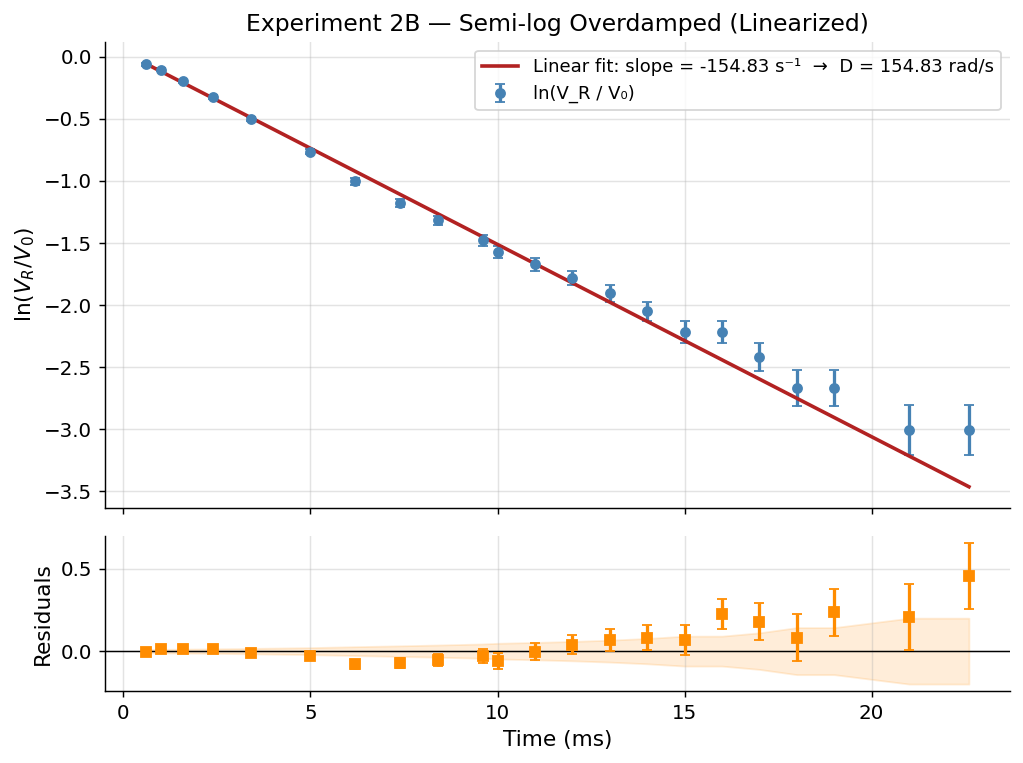

Figure 7 saved.


In [25]:
# ── Figure 7: Semi-log of overdamped data ─────────────────────
ln_V_2B        = np.log(V_norm_2B[mask_slow])
sigma_lnV_2B   = sigma_Vnorm_2B / V_norm_2B[mask_slow]

popt_ln2B, pcov_ln2B = curve_fit(
    lin_model, t_2B[mask_slow], ln_V_2B,
    sigma=sigma_lnV_2B, absolute_sigma=True
)
perr_ln2B = np.sqrt(np.diag(pcov_ln2B))
D_lin_2B  = -popt_ln2B[0];  dD_lin_2B = perr_ln2B[0]
print(f"Semi-log linear fit: D_lin = {D_lin_2B:.4f} ± {dD_lin_2B:.4f} rad/s")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

ax1.errorbar(t_2B[mask_slow]*1e3, ln_V_2B, yerr=sigma_lnV_2B,
             fmt='o', color='steelblue', ms=5, capsize=3, label='ln(V_R / V₀)')
t_lin_plot_2B = np.linspace(t_2B[mask_slow][0], t_2B[mask_slow][-1], 200)
ax1.plot(t_lin_plot_2B*1e3, lin_model(t_lin_plot_2B, *popt_ln2B), '-', color='firebrick', lw=2,
         label=fr'Linear fit: slope = {popt_ln2B[0]:.2f} s⁻¹  →  D = {D_lin_2B:.2f} rad/s')
ax1.set_ylabel('ln($V_R / V_0$)')
ax1.set_title('Experiment 2B — Semi-log Overdamped (Linearized)')
ax1.legend()

resid_ln2B = ln_V_2B - lin_model(t_2B[mask_slow], *popt_ln2B)
ax2.axhline(0, color='black', lw=0.8)
ax2.errorbar(t_2B[mask_slow]*1e3, resid_ln2B, yerr=sigma_lnV_2B,
             fmt='s', color='darkorange', ms=5, capsize=3)
ax2.fill_between(t_2B[mask_slow]*1e3, -sigma_lnV_2B, sigma_lnV_2B, alpha=0.15, color='darkorange')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Residuals')

plt.tight_layout()
plt.savefig('fig7_2B_semilog.png', bbox_inches='tight')
plt.show()
print("Figure 7 saved.")


---
## Summary of All Results


In [26]:
print("=" * 75)
print("  COMPLETE RESULTS SUMMARY")
print("=" * 75)

print("\n── Experiment 1A: RC Discharge ──────────────────────────────────────")
print(f"  τ_experimental = {B_fit_1A:.4f} ± {dB_fit_1A:.4f} s")
print(f"  τ_theoretical  = {tau_theory_1A:.4f} ± {dtau_theory_1A:.4f} s")
t1A = agreement_test(B_fit_1A, dB_fit_1A, tau_theory_1A, dtau_theory_1A, label="  1A τ")

print("\n── Experiment 1B: Homemade Capacitor ────────────────────────────────")
print(f"  τ_experimental = {tau_fit_1B:.4f} ± {dtau_fit_1B:.4f} s")
print(f"  C_measured     = {C_home*1e6:.2f} ± {dC_home*1e6:.2f} μF")
print(f"  C_theoretical  = {C_theory_1B*1e9:.2f} nF  (full-paper estimate)")
print(f"  Ratio           = {C_home/C_theory_1B:.0f}× larger than paper estimate")
print(f"  d_effective     = {d_eff*1e3:.3f} ± {dd_eff*1e3:.3f} mm  (nominal paper = 0.10 mm)")

print("\n── Experiment 2A: RLC Underdamped ───────────────────────────────────")
print(f"  α_experimental = {alpha_fit:.1f} ± {dalpha_fit:.1f} rad/s")
print(f"  α_theoretical  = {alpha_theory_2A_withRL:.1f} ± {dalpha_theory_2A_withRL:.1f} rad/s  (with R_L = {R_L_inferred:.1f} Ω)")
t2Aa = agreement_test(alpha_fit, dalpha_fit, alpha_theory_2A_withRL, dalpha_theory_2A_withRL, label="  2A α")
print(f"  ω₀_experimental= {omega0_exp_2A:.1f} ± {domega0_exp_2A:.1f} rad/s")
print(f"  ω₀_theoretical = {omega0_theory_2A:.1f} ± {domega0_theory_2A:.1f} rad/s")
t2Ab = agreement_test(omega0_exp_2A, domega0_exp_2A, omega0_theory_2A, domega0_theory_2A, label="  2A ω₀")
print(f"  ω_exp          = {omega_exp_2A:.1f} ± {domega_exp_2A:.1f} rad/s  (from peak spacing)")
print(f"  T_exp          = {T_exp*1e6:.1f} ± {dT_exp*1e6:.1f} μs")

print("\n── Experiment 2B: RLC Overdamped ─────────────────────────────────────")
print(f"  D_experimental = {D_fit_2B:.2f} ± {dD_fit_2B:.2f} rad/s   (τ_exp = {tau_fit_2B*1000:.2f} ms)")
print(f"  D_slow_theory  = {D_slow_theory:.4f} ± {dD_slow_theory:.4f} rad/s   (τ_theory = {tau_slow*1000:.1f} ms)")
t2B = agreement_test(D_fit_2B, dD_fit_2B, D_slow_theory, dD_slow_theory, label="  2B D_slow")
print(f"  D_fast_theory  = {D_fast_theory:.2f} rad/s  (τ_fast = {tau_fast*1000:.4f} ms)")

print("\n" + "=" * 75)


  COMPLETE RESULTS SUMMARY

── Experiment 1A: RC Discharge ──────────────────────────────────────
  τ_experimental = 0.6125 ± 0.0061 s
  τ_theoretical  = 0.4700 ± 0.0240 s
  1A τ: t = 5.77  →  DISAGREE ✗

── Experiment 1B: Homemade Capacitor ────────────────────────────────
  τ_experimental = 0.3171 ± 0.0227 s
  C_measured     = 31.71 ± 2.29 μF
  C_theoretical  = 20.30 nF  (full-paper estimate)
  Ratio           = 1562× larger than paper estimate
  d_effective     = 0.000 ± 0.000 mm  (nominal paper = 0.10 mm)

── Experiment 2A: RLC Underdamped ───────────────────────────────────
  α_experimental = 703.1 ± 17.8 rad/s
  α_theoretical  = 703.1 ± 101.1 rad/s  (with R_L = 90.6 Ω)
  2A α: t = 0.00  →  AGREE ✓
  ω₀_experimental= 10051.0 ± 43.5 rad/s
  ω₀_theoretical = 10000.0 ± 559.0 rad/s
  2A ω₀: t = 0.09  →  AGREE ✓
  ω_exp          = 10026.4 ± 43.5 rad/s  (from peak spacing)
  T_exp          = 626.7 ± 2.7 μs

── Experiment 2B: RLC Overdamped ─────────────────────────────────────
  D_exper

---
## Notes on Data Corrections

The following issues were found in the original notebook and corrected:

1. **Experiment 1A `times` array:** A missing comma between `-0.952` and `-0.896` caused Python to evaluate their concatenation as a float subtraction (`-0.952 - 0.896 = -1.848`). Restored to two separate values.

2. **Experiment 1A `values` array:** `8,6` was interpreted as `8` and `6` (two elements), where it should be `8.6` (a single decimal number). Corrected to `8.6`.

3. **Experiment 1B `times` array:** A missing comma between `-1.644` and `-1.628` caused the same concatenation bug. Restored to two separate values.

4. **Experiment 2B:** The `times` array had 26 entries while `values` had 25. The extra entry (25 ms) had no corresponding voltage measurement and was dropped.

5. **Experiment 2A units:** The times in microseconds were divided by 1000 in the original, placing them in **milliseconds**, not seconds. The analysis treats them correctly as microseconds → seconds.
